In [1]:
import os
MAIN_DIR='/home/jovyan/code4'
os.chdir(MAIN_DIR)
print(os.getcwd())

/home/jovyan/code4


In [2]:
import json
import numpy as np
import scipy.sparse.linalg as sprse
import pickle
import random
import os
from pathlib import Path as Data_Path
from basic_types import JSONFile
from tqdm import tqdm
import networkx as nx
from networkx.algorithms import bipartite
from graph_building_routines import graph_attribute_builder

import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({ "text.usetex": True, "font.family": "serif" })
font = {'size': 16}
matplotlib.rc('font', **font)
fmt = 'pdf'
%matplotlib inline

In [3]:
Gred = pickle.load(open(f"amazon_{26}core.pkl", "rb"))


kcore_selected_users = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="user"]
kcore_selected_items = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="item"]
num_users = len(kcore_selected_users)
num_items = len(kcore_selected_items)
print(f"Number of kcore selected users: {num_users}")
print(f"Number of kcore selected items: {num_items}")

Number of kcore selected users: 9103
Number of kcore selected items: 9766


In [4]:
def subgraph_count(bmat, degrees):

    # A = (0 bmat \\ bmat.T 0)
    # A2 = (bmat@bmat.T 0 \\ 0 bmat.T@bmat)
    # we leverage the block structure in order to speed up computation.  

    fvec = np.zeros(5)
    nplylsts, ntrcks = bmat.shape
    nds = nplylsts + ntrcks

    dgs = np.zeros((nds, 1), dtype=int)
    ovec = np.ones((nds, 1), dtype=int)
    dfvec = np.zeros((nds, 1), dtype=int)
    dftvec = np.zeros((nds, 1), dtype=int)
    dgs[:, 0] = degrees.astype(int)
    dfvec[:, 0] = dgs[:, 0] - ovec[:, 0]
    dftvec[:, 0] = dgs[:, 0] - 2 * ovec[:, 0]

    dfvecu = dfvec[:nplylsts,:]
    dfvecl = dfvec[nplylsts:,:]

    A2u = bmat @ bmat.T
    A2l = bmat.T @ bmat

    P1 = np.sum(dgs)/2    
    P2 = np.sum(dgs*dfvec) / 2.
    A2m1u = A2u.todense()-np.ones(A2u.shape)
    A2m1l = A2l.todense()-np.ones(A2l.shape)
    a2chsu = .5*A2u.todense()*A2m1u
    a2chsl = .5*A2l.todense()*A2m1l

    np.fill_diagonal(a2chsu, 0.)
    np.fill_diagonal(a2chsl, 0.)
    
    a2chsvecu = np.sum(a2chsu, 1)
    a2chsvecl = np.sum(a2chsl, 1)
    a2chsvec = np.concatenate((a2chsvecu, a2chsvecl))

    fvec[0] = P1 # num edges
    fvec[1] = P2 # n_G(H_2)
    fvec[2] = .5*( np.sum( np.sum( bmat*(dfvecu@dfvecl.T) ) ) + np.sum( np.sum( bmat.T*(dfvecl@dfvecu.T) ) ) )# n_G(H_3)
    fvec[3] = np.sum(dgs[:, 0]*dfvec[:, 0]*dftvec[:, 0]) / 6.  # n_G(H_4)    
    fvec[4] = np.dot(dftvec[:,0], a2chsvec) # n_G(H_9)

    return fvec

In [5]:
bmat = bipartite.biadjacency_matrix(Gred, row_order=kcore_selected_users, column_order=set(kcore_selected_items), dtype=np.float64)
d1 = np.sum(bmat, axis=1)
d2 = np.sum(bmat, axis=0)
degrees = np.concatenate((d1, d2))
print(degrees[:10].astype(int))

[119  74  38  35  53  61  78  55  54 441]


In [6]:
fvals = subgraph_count(bmat, degrees)

In [7]:
print(fvals[0])

539347.0


In [7]:
svals = sprse.svds(bmat,k=500,which='LM',return_singular_vectors=False)

110.18923284328189


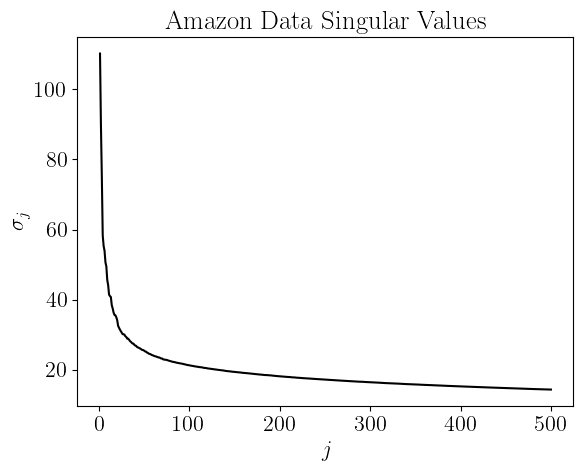

In [17]:
plt.plot(np.arange(1,len(svals)+1), svals[::-1],color='k')
#plt.xlim([.1, len(svals)])
plt.xlabel(r"$j$")
plt.ylabel(r"$\sigma_j$")
plt.title("Amazon Data Singular Values")
print(svals[-1])

#plt.savefig("a_singular_values.pdf", dpi=150, bbox_inches='tight')

110.18923284328179


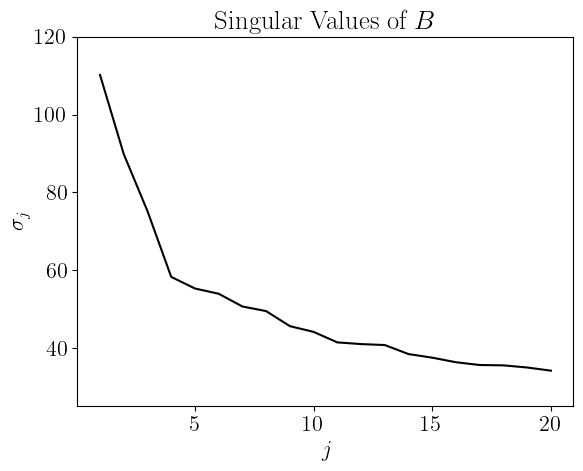

In [16]:
plt.plot(np.arange(1,21), svals[::-1][:20],color='k')
#plt.xlim([.1, len(svals)])
plt.xlabel(r"$j$")
plt.ylabel(r"$\sigma_j$")
plt.ylim(25, 120)
plt.title(r"Singular Values of $B$")
print(svals[-1])

plt.savefig("a_singular_values.pdf", dpi=150, bbox_inches='tight')

[9.57905245e+07 4.50251716e+11 3.43330632e+15]
54301753.0


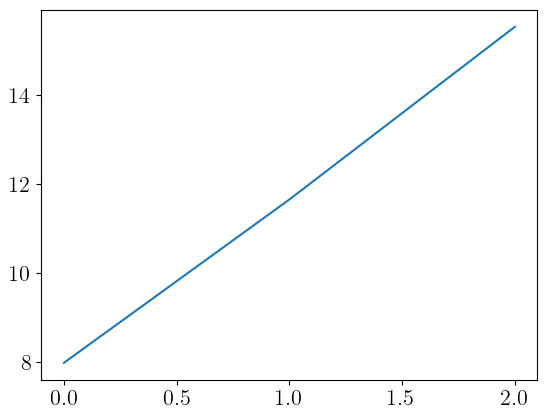

In [8]:
svals2 = svals*svals
svals2k = svals2[:]
kmax = 3
trace_vals = np.zeros(kmax, dtype=np.float64)
for jj in range(kmax):
    svals2k = svals2k*svals2
    kval = jj+2
    #trace_vals[jj] = (np.sum(svals2k) -2*kval*(2**(kval-1)-1)*fvals[1] -2 * fvals[0])/(4.*kval)
    trace_vals[jj] = np.sum(svals2k)/(2.*kval)
print(trace_vals)
print(fvals[1])
plt.plot(np.log10(trace_vals))

In [9]:
C4 = trace_vals[0] - (4*fvals[1]+2*fvals[0])/8
C6 = trace_vals[1] - (24*C4 + 6*fvals[2]+12*fvals[3]+12*fvals[4]+18*fvals[1]+2*fvals[0])/12
print(trace_vals[1])
print(C6)
print(C6/trace_vals[1])

450251715812.2413
385846844695.59955
0.8569580773269078


5


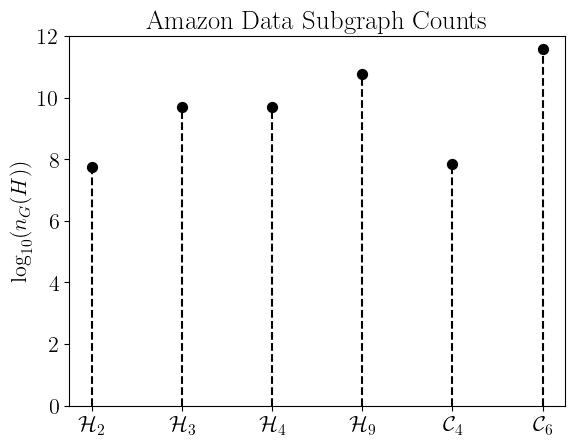

In [12]:
labels=[r'$\mathcal{H}_2$', r'$\mathcal{H}_3$', r'$\mathcal{H}_4$', r'$\mathcal{H}_9$', r'$\mathcal{C}_4$', r'$\mathcal{C}_6$']
print(fvals.size)
plotvals = np.concatenate((fvals[1:],np.array([C4, C6])))
fig, ax = plt.subplots()
ax.set_ylabel(r"$\log_{10}(n_{G}(H))$")
ax.scatter(np.arange(6),np.log10(plotvals),c='k',s=50.)
for jj in range(len(labels)):
    plt.plot([jj, jj], [0, np.log10(plotvals[jj])], c='k', ls='--')
ax.set_ylim([0,12])
ax.set_xticks(np.arange(6))
ax.set_xticklabels(labels)
plt.title("Amazon Data Subgraph Counts")
plt.savefig("a_subgraph_count.pdf", dpi=150, bbox_inches='tight')